### Prediction Notebook - Fragment-Based Molecular Generation
### フラグメントベース分子生成 予測ノートブック

HuggingFaceからダウンロードした学習済みモデルを使用して、任意のSMILESからフラグメントを抽出し、そのフラグメントを含む新しい分子を生成します。

#### モデル
- **T5Chem (RFFMG)**: T5ベースのTransformerモデル（`t5chem`環境で実行）

#### フラグメント化手法
- **BRICS**: BRICS分解による化学的に意味のあるフラグメント化
- **RC_CMS**: ランダムカットによるフラグメント化（SP3-SP3結合、環-環接続など）

### 0. 依存ライブラリのインストール


In [12]:
# T5Chem環境の場合

# 仮想環境の構築
!conda create -n t5chem python=3.12 -y

# パッケージのインストール
!conda run -n t5chem pip install -r requirements/t5chem_requirements.txt
!conda run -n t5chem pip install -e .

# カーネルとして登録
!conda run -n t5chem pip install ipykernel
!conda run -n t5chem python -m ipykernel install --user --name t5chem --display-name "t5chem"

print("✅ カーネルを 't5chem' に切り替えてから次のセルを実行してください")


UnboundLocalError: cannot access local variable 'child' where it is not associated with a value

--- Logging error ---
Traceback (most recent call last):
  File "/home/sato/miniconda3/envs/t5chem/lib/python3.12/site-packages/IPython/utils/_process_posix.py", line 125, in system
    child = pexpect.spawn(self.sh, args=['-c', cmd])  # Vanilla Pexpect
            ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/sato/miniconda3/envs/t5chem/lib/python3.12/site-packages/pexpect/pty_spawn.py", line 205, in __init__
    self._spawn(command, args, preexec_fn, dimensions)
  File "/home/sato/miniconda3/envs/t5chem/lib/python3.12/site-packages/pexpect/pty_spawn.py", line 303, in _spawn
    self.ptyproc = self._spawnpty(self.args, env=self.env,
                   ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/sato/miniconda3/envs/t5chem/lib/python3.12/site-packages/pexpect/pty_spawn.py", line 315, in _spawnpty
    return ptyprocess.PtyProcess.spawn(args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/sato/miniconda3/envs/t5chem/lib/python3.12/site-p

## 1. モデルのダウンロード

HuggingFace Hub (`sato-akinori/FFMG`) から学習済みモデルをダウンロードします。  
プライベートリポジトリの場合は、事前に `huggingface-cli login` でログインしてください。

In [6]:
import os
import glob
import subprocess
from huggingface_hub import snapshot_download

# HuggingFaceからモデルをダウンロード
snapshot_download(
    repo_id='sato-akinori/FFMG',
    allow_patterns='models/*',
    local_dir='.'
)

# zipファイルを解凍
for zip_file in glob.glob('models/**/*.zip', recursive=True):
    subprocess.run(['unzip', '-o', zip_file, '-d', os.path.dirname(zip_file)], check=True)
    os.remove(zip_file)

print('モデルのダウンロードが完了しました。')

/home/sato/miniconda3/envs/t5chem/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Fetching 6 files: 100%|██████████| 6/6 [00:10<00:00,  1.79s/it]


Archive:  models/t5chem/from_scratch/rffmg/rc_cms/best_model.zip
   creating: models/t5chem/from_scratch/rffmg/rc_cms/best_model/
  inflating: models/t5chem/from_scratch/rffmg/rc_cms/best_model/added_tokens.json  
  inflating: models/t5chem/from_scratch/rffmg/rc_cms/best_model/config.json  
  inflating: models/t5chem/from_scratch/rffmg/rc_cms/best_model/generation_config.json  
  inflating: models/t5chem/from_scratch/rffmg/rc_cms/best_model/model.safetensors  
  inflating: models/t5chem/from_scratch/rffmg/rc_cms/best_model/special_tokens_map.json  
  inflating: models/t5chem/from_scratch/rffmg/rc_cms/best_model/tokenizer_config.json  
  inflating: models/t5chem/from_scratch/rffmg/rc_cms/best_model/training_args.bin  
  inflating: models/t5chem/from_scratch/rffmg/rc_cms/best_model/vocab.txt  
Archive:  models/t5chem/from_scratch/rffmg/brics/best_model.zip
   creating: models/t5chem/from_scratch/rffmg/brics/best_model/
  inflating: models/t5chem/from_scratch/rffmg/brics/best_model/added_

## 2. 設定

フラグメント化手法、生成パラメータなどを設定します。

In [7]:
# ========================================
# 設定（必要に応じて変更してください）
# ========================================
FRAG_METHOD = 'brics'    # 'brics' or 'rc_cms'
N_SAMPLES   = 10         # 生成する分子数
NUM_BEAMS   = 10         # ビームサーチのビーム数
MAX_LENGTH  = 200        # 最大シーケンス長
RANDOM_SEED = 42         # 乱数シード

# モデルパス
T5CHEM_MODEL_PATH = f'models/t5chem/trained/rffmg/{FRAG_METHOD}/best_model/'

## 3. ライブラリのインポートとヘルパー関数

In [8]:
import sys
sys.path.insert(0, 'src')

import numpy as np
import pandas as pd
from rdkit import Chem
from rdkit.Chem import Draw
from IPython.display import display

from func.fragmentation import (
    BRICSFragmentize,
    RandomFragmentize,
    PostProcessSelectFrags,
)


def fragmentize_smiles(smiles, frag_method='brics', ratio=0.6, big_ring_thres=7, seed=42):
    """
    SMILESをフラグメント化する。
    
    Returns:
        pass_frags: フラグメントSMILES（環上のR基をトリム済み）
    """
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        raise ValueError(f'Invalid SMILES: {smiles}')

    if frag_method == 'brics':
        frags = BRICSFragmentize(mol, returnSmiles=False)
        trim_r_on_ring = False
    elif frag_method == 'rc_cms':
        frags = RandomFragmentize(
            mol, returnSmiles=False,
            bigRingThres=big_ring_thres, rseed=seed, ratio=ratio
        )
        trim_r_on_ring = True
    else:
        raise ValueError(f'Unknown method: {frag_method}')

    if frags is None:
        return None

    pass_frags, _ = PostProcessSelectFrags(
        frags,
        smallCarbonFilter=True,
        trimRgroupOnRing=trim_r_on_ring,
        uniquenize=(frag_method != 'brics'),
    )
    return pass_frags


print('ライブラリの読み込みが完了しました。')

The cache for model files in Transformers v4.22.0 has been updated. Migrating your old cache. This is a one-time only operation. You can interrupt this and resume the migration later on by calling `transformers.utils.move_cache()`.
0it [00:00, ?it/s]

ライブラリの読み込みが完了しました。


## 4. 入力SMILESとフラグメント化

任意のSMILESを入力し、フラグメント化を行います。  
`input_smiles` を変更して異なる分子で試してみてください。

入力分子 (canonical SMILES): CC(C)Cc1ccc(C(C)C(=O)O)cc1

--- フラグメント化結果 ---
手法: brics
フラグメント: *c1ccc(*)cc1.*C(C)C(=O)O
フラグメント数: 2


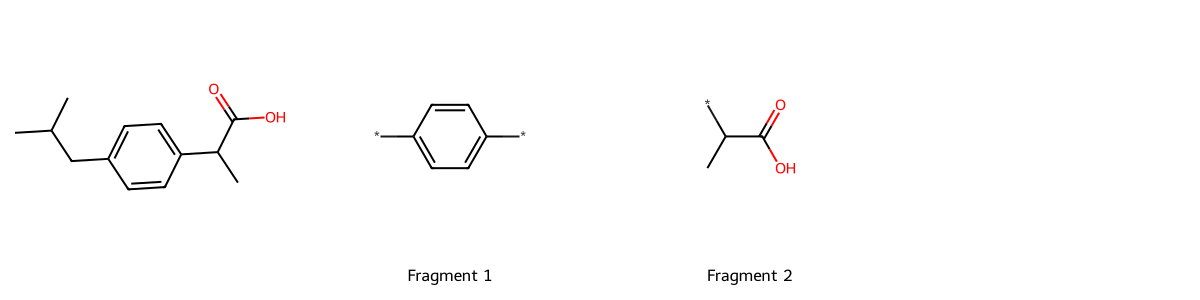

In [10]:
# ========================================
# 入力SMILES（変更可能）
# ========================================
input_smiles = 'CC(C)Cc1ccc(C(C)C(=O)O)cc1'  # イブプロフェン

# SMILESの検証と正規化
mol = Chem.MolFromSmiles(input_smiles)
assert mol is not None, '無効なSMILESです。正しいSMILESを入力してください。'
canonical_smi = Chem.MolToSmiles(mol)
print(f'入力分子 (canonical SMILES): {canonical_smi}')

# フラグメント化
pass_frags = fragmentize_smiles(canonical_smi, frag_method=FRAG_METHOD)

if pass_frags is None:
    print('この分子はフラグメント化できません。別のSMILESまたは手法を試してください。')
else:
    print(f'\n--- フラグメント化結果 ---')
    print(f'手法: {FRAG_METHOD}')
    print(f'フラグメント: {pass_frags}')
    print(f'フラグメント数: {len(pass_frags.split("."))}')

    # 入力分子とフラグメントの描画
    frag_mols = [Chem.MolFromSmiles(f) for f in pass_frags.split('.')]
    frag_mols = [m for m in frag_mols if m is not None]
    if frag_mols:
        img = Draw.MolsToGridImage(
            [mol] + frag_mols,
            molsPerRow=4,
            subImgSize=(300, 300),
            legends=['入力分子'] + [f'Fragment {i+1}' for i in range(len(frag_mols))]
        )
        display(img)

---
## 5. T5Chemモデルによる分子生成

**注意**: このセクションは `t5chem` 環境で実行してください。
```bash
conda activate t5chem
```

実行コマンド: t5chem predict --data_dir /tmp/tmpwtauso1l --model_dir models/t5chem/trained/rffmg/brics/best_model/ --prediction /tmp/tmpwtauso1l/predictions.csv --num_beams 10 --num_preds 10 --batch_size 1

--- T5Chem 生成結果 ---
入力フラグメント: *c1ccc(*)cc1.*C(C)C(=O)O


,target,prediction_1,prediction_2,prediction_3,prediction_4,prediction_5,prediction_6,prediction_7,prediction_8,prediction_9,prediction_10,rank
0,CC(C)Cc1ccc(C(C)C(=O)O)cc1,COc1ccc(C(C)C(=O)O)cc1,CC(C(=O)O)c1ccc(-c2ccccc2)cc1,CC(C(=O)O)c1ccc(C(=O)c2ccccc2)cc1,CC(C(=O)O)c1ccc(C(C)(C)C)cc1,COc1ccc(OC(C)C(=O)O)cc1,CC(C(=O)O)c1ccc(C(F)(F)F)cc1,CC(C(=O)O)c1ccc(Cc2ccccc2)cc1,CC(=O)c1ccc(OC(C)C(=O)O)cc1,CC(C(=O)O)c1ccc(OCc2ccccc2)cc1,CC(C(=O)O)c1ccc(-c2ccc(Cl)cc2)cc1,0


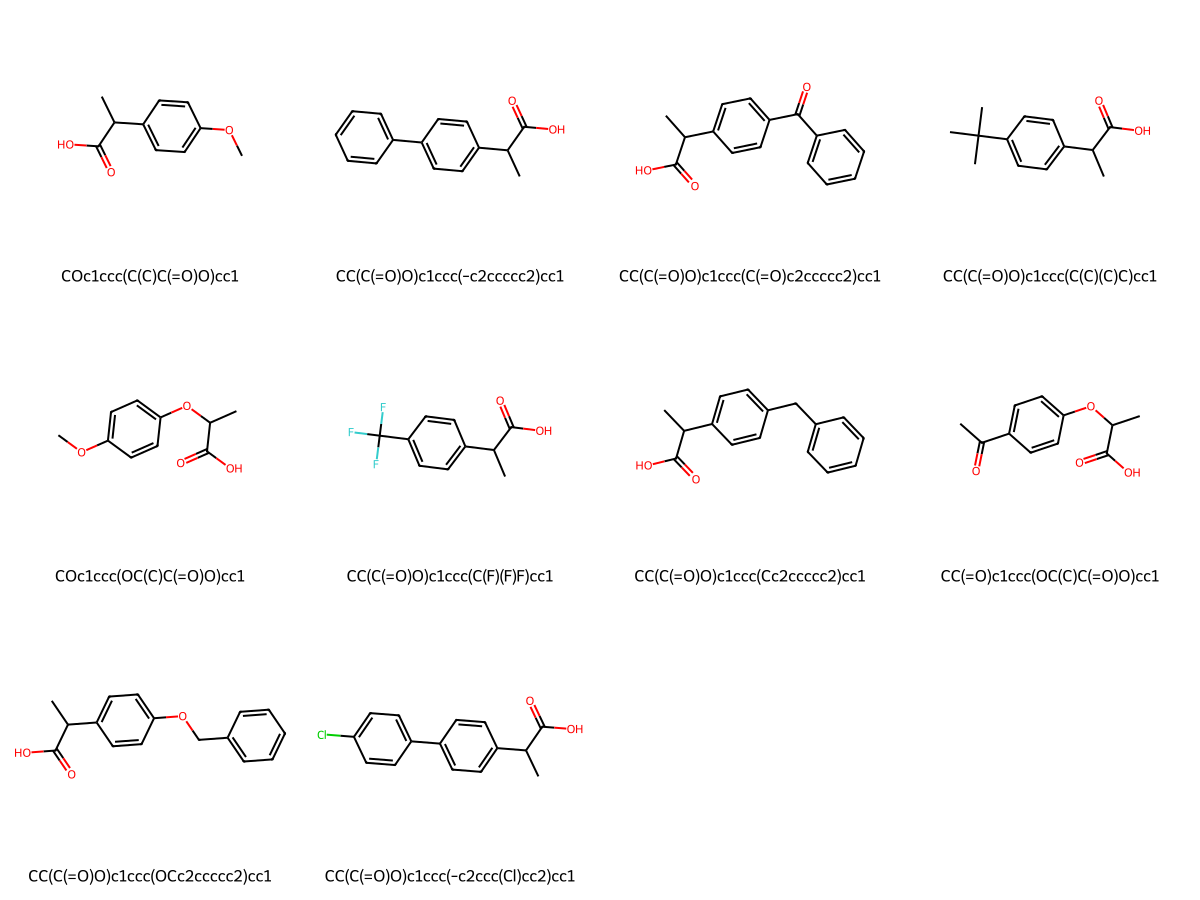

In [11]:
import subprocess
import tempfile

assert pass_frags is not None, 'フラグメント化が失敗しています。セクション4を確認してください。'

with tempfile.TemporaryDirectory() as tmpdir:
    # ソースファイル（フラグメント）の書き込み
    with open(os.path.join(tmpdir, 'test.source'), 'w') as f:
        f.write(pass_frags + '\n')

    # ターゲットファイル（ダミー、t5chemに必須）の書き込み
    with open(os.path.join(tmpdir, 'test.target'), 'w') as f:
        f.write(canonical_smi + '\n')

    pred_file = os.path.join(tmpdir, 'predictions.csv')

    cmd = [
        't5chem', 'predict',
        '--data_dir', tmpdir,
        '--model_dir', T5CHEM_MODEL_PATH,
        '--prediction', pred_file,
        '--num_beams', str(NUM_BEAMS),
        '--num_preds', str(N_SAMPLES),
        '--batch_size', '1',
    ]

    print(f'実行コマンド: {" ".join(cmd)}')
    result = subprocess.run(cmd, capture_output=True, text=True)

    if result.returncode != 0:
        print(f'エラー: {result.stderr}')
    else:
        t5chem_df = pd.read_csv(pred_file)
        print(f'\n--- T5Chem 生成結果 ---')
        print(f'入力フラグメント: {pass_frags}')
        display(t5chem_df)

        # 生成分子の描画
        pred_smiles = [
            t5chem_df.iloc[0, i]
            for i in range(1, min(N_SAMPLES + 1, len(t5chem_df.columns)))
            if isinstance(t5chem_df.iloc[0, i], str)
        ]
        pred_mols = [Chem.MolFromSmiles(s) for s in pred_smiles]
        pred_mols = [m for m in pred_mols if m is not None]
        if pred_mols:
            img = Draw.MolsToGridImage(
                pred_mols[:12], molsPerRow=4, subImgSize=(300, 300),
                legends=[Chem.MolToSmiles(m) for m in pred_mols[:12]]
            )
            display(img)